# Multi-Class CART Classification — Jabalpur

Land cover classification over the Jabalpur district using CART.
Training points are spread across Jabalpur (excluding the campus).

**Key details:**
- Labels are explicitly assigned to each collection (forest=0, water=1, buildings=2, soil=3)
- Extended date range: full dry season (Oct 2024 – May 2025) for gap-free composite
- Scene-level cloud filter relaxed to 50% (per-pixel QA60 masking handles individual clouds)
- No restrictive maxNodes cap — tree grows to full depth with minLeafPopulation=5

In [7]:
import os
import ee
import geemap
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()
ee.Initialize(project=os.getenv('EE_PROJECT_ID'))

os.makedirs('../../../doc/assets', exist_ok=True)

In [8]:
# ----- Define Jabalpur District Boundary -----
jabalpur = (
    ee.FeatureCollection('FAO/GAUL/2015/level2')
      .filter(ee.Filter.eq('ADM2_NAME', 'Jabalpur'))
      .geometry()
)

# ----- Cloud Masking -----
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud  = 1 << 10
    cirrus = 1 << 11
    mask = qa.bitwiseAnd(cloud).eq(0).And(qa.bitwiseAnd(cirrus).eq(0))
    return image.updateMask(mask).divide(10000)

def _add_spectral_indices(composite):
    ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndwi = composite.normalizedDifference(['B3', 'B8']).rename('NDWI')
    ndbi = composite.normalizedDifference(['B11', 'B8']).rename('NDBI')
    savi = composite.expression(
        '1.5 * (NIR - RED) / (NIR + RED + 0.5)',
        {'NIR': composite.select('B8'), 'RED': composite.select('B4')}
    ).rename('SAVI')
    bsi = composite.expression(
        '((SWIR1 + RED) - (NIR + BLUE)) / ((SWIR1 + RED) + (NIR + BLUE))',
        {
            'SWIR1': composite.select('B11'),
            'RED': composite.select('B4'),
            'NIR': composite.select('B8'),
            'BLUE': composite.select('B2')
        }
    ).rename('BSI')
    return composite.addBands([ndvi, ndwi, ndbi, savi, bsi])


def _add_topography(composite, geometry):
    dem = ee.Image("USGS/SRTMGL1_003").clip(geometry)
    elevation = dem.select("elevation").rename("ELEVATION")
    slope = ee.Terrain.slope(dem).rename("SLOPE")
    return composite.addBands([elevation, slope])

def _build_collection(geometry, start_date, end_date, cloud_threshold=40):
    return (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterDate(start_date, end_date)
        .filterBounds(geometry)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloud_threshold))
        .map(mask_s2_clouds)
    )

def build_multi_temporal_stack(geometry, year="2025", cloud_threshold=40):
    seasons = {
        "winter": (f"{int(year)-1}-12-01", f"{year}-02-28"),
        "summer": (f"{year}-03-01", f"{year}-05-31"),
        "postmonsoon": (f"{year}-09-01", f"{year}-11-30")
    }
    
    stacked_image = None
    base_bands = ["B2", "B3", "B4", "B8", "B11", "B12", "NDVI", "NDWI", "NDBI", "SAVI", "BSI", "ELEVATION", "SLOPE"]
    
    for season_name, (start_date, end_date) in seasons.items():
        collection = _build_collection(geometry, start_date, end_date, cloud_threshold)
        composite = collection.median().clip(geometry)
        composite = _add_spectral_indices(composite)
        composite = _add_topography(composite, geometry)
        
        seasonal_composite = composite.select(base_bands)
        new_names = [f"{band}_{season_name}" for band in base_bands]
        seasonal_composite = seasonal_composite.rename(new_names)
        
        if stacked_image is None:
            stacked_image = seasonal_composite
        else:
            stacked_image = stacked_image.addBands(seasonal_composite)
            
    return stacked_image

composite = build_multi_temporal_stack(jabalpur, year="2025")

base_bands = ["B2", "B3", "B4", "B8", "B11", "B12", "NDVI", "NDWI", "NDBI", "SAVI", "BSI", "ELEVATION", "SLOPE"]
bands = (
    [f"{b}_winter" for b in base_bands] +
    [f"{b}_summer" for b in base_bands] +
    [f"{b}_postmonsoon" for b in base_bands]
)
print("Total bands:", len(bands))


Total bands: 39


In [9]:
# ----- Load Jabalpur Training Points -----
forest = ee.FeatureCollection("users/cosypix/jabalpur_forest_points").map(lambda f: f.set('label', 0))
water = ee.FeatureCollection("users/cosypix/jabalpur_water_points").map(lambda f: f.set('label', 1))
buildings = ee.FeatureCollection("users/cosypix/jabalpur_urban_points").map(lambda f: f.set('label', 2))
barren_base = ee.FeatureCollection("users/cosypix/jabalpur_barren_points")
sand_base = ee.FeatureCollection("users/cosypix/jabalpur_sand_points")
barren = barren_base.merge(sand_base).map(lambda f: f.set('label', 3))
agriculture = ee.FeatureCollection("users/cosypix/jabalpur_agriculture_points").map(lambda f: f.set('label', 4))

class_names = ['Forest', 'Water', 'Urban / Buildings', 'Barren Land', 'Agricultural Land']
class_collections = [forest, water, buildings, barren, agriculture]

print('--- Raw Points per Class ---')
total_points = 0
for name, fc in zip(class_names, class_collections):
    count = fc.size().getInfo()
    total_points += count
    print(f'{name}: {count}')
print(f'Total Points: {total_points}')
print()

all_points = forest.merge(water).merge(buildings).merge(barren).merge(agriculture)

# ----- Sample & Split -----
training = (
    composite.select(bands)
             .sampleRegions(
                 collection=all_points,
                 properties=['label'],
                 scale=10,
                 tileScale=4
             )
             .filter(ee.Filter.notNull(bands + ['label']))
             .randomColumn('random', 42)
)

# ----- Diagnostic: check per-class sample counts after sampling -----
sampled_total = training.size().getInfo()
print(f'--- Sampled Points (after notNull filter): {sampled_total} / {total_points} ---')
for i, name in enumerate(class_names):
    count = training.filter(ee.Filter.eq('label', i)).size().getInfo()
    print(f'{name} (label={i}): {count}')
print()

train_set = training.filter(ee.Filter.lt('random', 0.7))
test_set  = training.filter(ee.Filter.gte('random', 0.7))
print('Train Set Size:', train_set.size().getInfo())
print('Test Set Size:', test_set.size().getInfo())


--- Raw Points per Class ---
Forest: 1002
Water: 1000
Urban / Buildings: 1060
Barren Land: 1500
Agricultural Land: 1000
Total Points: 5562

--- Sampled Points (after notNull filter): 4373 / 5562 ---
Forest (label=0): 924
Water (label=1): 781
Urban / Buildings (label=2): 868
Barren Land (label=3): 1053
Agricultural Land (label=4): 747

Train Set Size: 3116
Test Set Size: 1257


Overall Accuracy: 0.9331742243436754
Kappa Coefficient: 0.9160762457655812

--- Confusion Matrix Shape Check ---
Rows: 5 Cols: 5
[[249, 2, 2, 5, 2], [2, 216, 1, 1, 1], [1, 1, 219, 15, 14], [0, 1, 11, 295, 1], [6, 3, 15, 0, 194]]

--- Class-wise Accuracy ---
Forest: Consumer's = 0.9651, Producer's = 0.9577
Water: Consumer's = 0.9686, Producer's = 0.9774
Urban / Buildings: Consumer's = 0.8831, Producer's = 0.8760
Barren Land: Consumer's = 0.9335, Producer's = 0.9578
Agricultural Land: Consumer's = 0.9151, Producer's = 0.8899



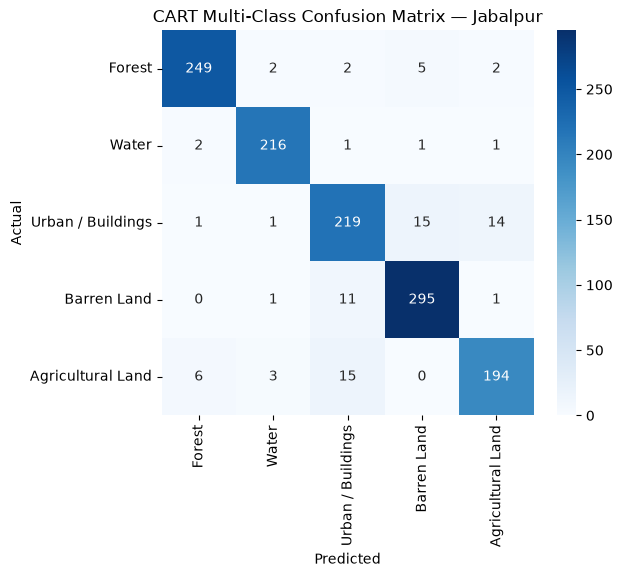

In [10]:
# ----- Train the CART Classifier -----
cart_classifier = ee.Classifier.smileCart(
    minLeafPopulation=5
).setOutputMode('CLASSIFICATION').train(
    features=train_set,
    classProperty='label',
    inputProperties=bands
)

# ----- Evaluate on Test Set -----
test_classified = test_set.classify(cart_classifier)
confusion_matrix = test_classified.errorMatrix('label', 'classification')

print('Overall Accuracy:', confusion_matrix.accuracy().getInfo())
print('Kappa Coefficient:', confusion_matrix.kappa().getInfo())

# --- Matrix shape / sanity check (Step 2) ---
# Confirms the confusion matrix is actually 4x4 and shows the raw
# counts, so a missing/empty row or column is visible directly
# instead of being masked by a misleading 0.0000 accuracy value.
cm_array = confusion_matrix.array().getInfo()
print('\n--- Confusion Matrix Shape Check ---')
print('Rows:', len(cm_array), 'Cols:', len(cm_array[0]) if cm_array else 0)
print(cm_array)

# --- Class-wise Accuracy (Step 3: label-aligned, not position-flattened) ---
# errorMatrix.order() returns the actual label order GEE used to build
# the matrix. Mapping consumers/producers accuracy through this order
# (instead of assuming positions 0,1,2,3 line up with class_names)
# means a genuinely missing class shows up as NaN, not a silent 0.0000.
print('\n--- Class-wise Accuracy ---')
order = confusion_matrix.order().getInfo()
consumers_acc = confusion_matrix.consumersAccuracy().getInfo()
producers_acc = confusion_matrix.producersAccuracy().getInfo()

ca_flat = [item for sublist in consumers_acc for item in sublist]
pa_flat = [item for sublist in producers_acc for item in sublist]

ca_by_label = dict(zip(order, ca_flat))
pa_by_label = dict(zip(order, pa_flat))

for i, name in enumerate(class_names):
    ca = ca_by_label.get(i, float('nan'))
    pa = pa_by_label.get(i, float('nan'))
    print(f"{name}: Consumer's = {ca:.4f}, Producer's = {pa:.4f}")

print()

# ----- Confusion Matrix Heatmap -----
plt.figure(figsize=(6, 5))
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CART Multi-Class Confusion Matrix — Jabalpur')
plt.savefig('../../../doc/assets/multi_cart_jabalpur_cm.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
composite_jabalpur = composite.clip(jabalpur)

# 2. Run classification on the clipped composite
classified = composite_jabalpur.select(bands).classify(cart_classifier)

# 3. Apply spatial smoothing filter (1px square kernel)
classified_smooth = classified.focalMode(radius=1, kernelType='square', units='pixels')

# 4. Updated 5-Class Palette (0: Forest, 1: Water, 2: Buildings, 3: Barren, 4: Agriculture)
class_palette = ['006400', '0000FF', 'FF0000', 'B8860B', '7CFC00']

legend_dict = {
    'Forest (0)':            '006400',
    'Water (1)':             '0000FF',
    'Buildings (2)':         'FF0000',
    'Barren Land (3)':       'B8860B',
    'Agricultural Land (4)': '7CFC00'
}

# 5. Initialize Map
Map = geemap.Map(center=[23.18, 79.95], zoom=10)

# NOTE: If 'composite_jabalpur' is your 30-band stack, use seasonal band names:
# e.g., ['B4_winter', 'B3_winter', 'B2_winter']. 
# If it is a standard single-date composite, keep ['B4', 'B3', 'B2'].
Map.addLayer(
    composite_jabalpur, 
    {'bands': ['B4_winter', 'B3_winter', 'B2_winter'], 'min': 0, 'max': 0.3}, 
    'Winter RGB Composite'
)

# Added max=4 for the 5-class range (0 to 4)
Map.addLayer(
    classified_smooth, 
    {'min': 0, 'max': 4, 'palette': class_palette}, 
    'RF 5-Class Classification'
)

# Reliable outline-only styling for the Jabalpur boundary
Map.addLayer(jabalpur, {'color': 'white', 'fillColor': '00000000', 'width': 2}, 'Jabalpur Boundary')
Map.add_legend(title='Land Cover (5 Classes)', legend_dict=legend_dict)

Map

Map(center=[23.18, 79.95], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [12]:
# ----- Class-wise Area Calculation -----
area_image = ee.Image.pixelArea().addBands(classified_smooth)
areas = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
    geometry=jabalpur,
    scale=30,
    maxPixels=1e13,
    tileScale=4
)

area_data = areas.getInfo()['groups']
print('--- Class Areas (Hectares) ---')
for entry in area_data:
    ha = entry['sum'] / 10000
    print(f"{class_names[entry['class']]}: {ha:.2f} ha")

--- Class Areas (Hectares) ---
Forest: 78971.77 ha
Water: 13142.49 ha
Urban / Buildings: 61945.09 ha
Barren Land: 59083.17 ha
Agricultural Land: 188017.51 ha
